<a href="https://colab.research.google.com/github/snig-17/QM-GRUNGE/blob/main/Rough_work/alice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving expeditions3.csv to expeditions3.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly
import plotly.express as px
import warnings
from statsmodels.formula.api import ols
from statsmodels.iolib.summary2 import summary_col
import re
import io
warnings.filterwarnings('ignore')
sns.set(font_scale=0.75)
sns.set_style("white")
plt.rcParams['figure.figsize'] = (8, 5)

In [3]:
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))

In [4]:
df_recent = df[df['Year'] >= 1990]
df_recent['hired_DR'] = pd.to_numeric(df_recent['hired_DR'], errors='coerce').fillna(0)
df_recent['mbr_DR'] = pd.to_numeric(df_recent['mbr_DR'], errors='coerce').fillna(0)
grouped_df = df_recent.groupby('Year')[['hired_DR', 'mbr_DR']].mean().reset_index()


In [5]:
df_recent['clean_routes'] = (
    df_recent['Route(s)']
    .dropna()
    .str.lower()
    .str.replace(r'\(.*?\)', '', regex=True)
    .str.replace(',', '/', regex=False)
    .str.replace(';', '/', regex=False)        # normalize separators
    .str.split('/')                            # split routes
    .str[0]                                    # keep FIRST route only
    .str.replace(r'\s+', ' ', regex=True)      # normalize spaces
    .str.strip()
)

route_counts = df_recent['clean_routes'].value_counts().head(10)

df_recent['route_codes'] = (
    df_recent['clean_routes']
    .map({
        's col-se ridge': 1,
        'n col-ne ridge': 2,
        'n face': 3,
        'sw face': 4,
        's pillar-se ridge': 5,
        'n col': 1,
    })
    .fillna(6)
)

In [6]:
df_recent['Result_clean'] = (
    df_recent['Result']
    .astype(str)                 # handle NaN safely
    .str.lower()                 # ignore capitalisation
    .str.replace(r'\(.*?\)', '', regex=True)  # remove parenthetical notes
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()    # normalize spaces
)

df_recent['result_code'] = (
    df_recent['Result_clean']
    .map({
        'success': 1,
        'accident': 2,
        'route difficulty': 3,
        'illness, ams': 4,
        'lack of supplies': 5,
        'bad weather': 6,
        'bad conditions': 6,
        'other': 7,
        'lack of time': 8,
        'did not climb': 9,
        'unknown': 10
    })
    .fillna(11)
    .astype(int)
)
grouped_results = df_recent.groupby('Year')[['result_code']].mean().reset_index()


In [7]:
df_recent['mbr_hired_ratio'] = pd.to_numeric(df_recent['mbr_hired_ratio'], errors='coerce').fillna(0)
df_recent['mbr_hired_ratio'] = df_recent['mbr_hired_ratio'].where(df_recent['mbr_hired_ratio'] >= 0)
df_recent['OVERALL'] = pd.to_numeric(df_recent['OVERALL'], errors='coerce').fillna(0)

grouped_df3 = df_recent.groupby('Year')[['mbr_hired_ratio']].mean().reset_index()
grouped_df_DR = df_recent.groupby('Year')[['OVERALL']].mean().reset_index()

df_recent['Sucess_rate']= np.where(df_recent['Result_clean'] == 'success', 1, 0)
grouped_success = df_recent.groupby('Year')['Sucess_rate'].mean().reset_index()
yearly_popularity = df_recent.groupby('Year')['member_count'].sum().reset_index()


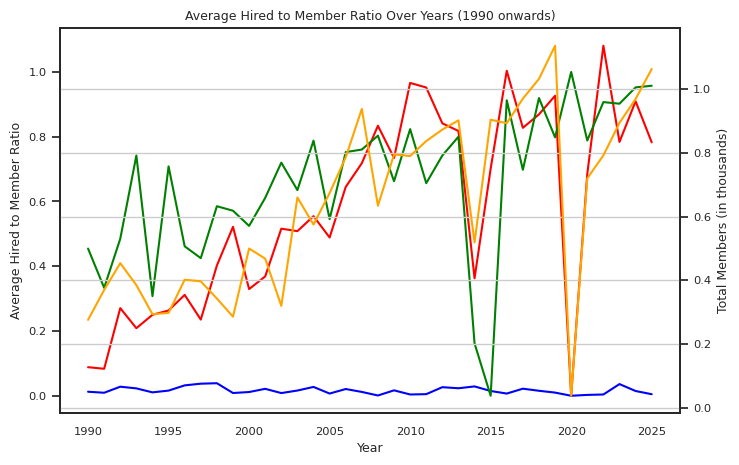

In [8]:
fig, ax = plt.subplots()
ax.plot(grouped_df3['Year'], grouped_df3['mbr_hired_ratio'], label='Hired to Member Ratio', color='red')
ax.plot(grouped_df_DR['Year'], grouped_df_DR['OVERALL'], label='Overall Death Rate', color='blue')
ax.plot(grouped_success['Year'], grouped_success['Sucess_rate'], label='Success Rate', color='green')
ax2 = ax.twinx()
ax2.plot(yearly_popularity['Year'], yearly_popularity['member_count']/1000, label='Total Members (scaled)', color='orange')
ax.set_xlabel('Year')
ax.set_ylabel('Average Hired to Member Ratio')
ax2.set_ylabel('Total Members (in thousands)')
ax.set_title('Average Hired to Member Ratio Over Years (1990 onwards)')
plt.grid()
plt.show()

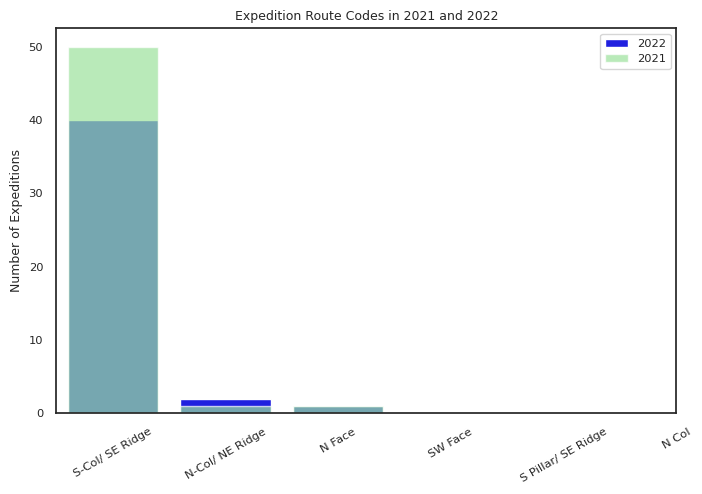

In [9]:
#ignore
df2022 = df_recent[df_recent['Year'] == 2022]
df2021 = df_recent[df_recent['Year'] == 2021]
sns.countplot(data=df_recent[df_recent['Year'] == 2022], x='route_codes', order=sorted(df2022['route_codes'].unique()), color='blue')
sns.countplot(data=df_recent[df_recent['Year'] == 2021], x='route_codes', order=sorted(df2021['route_codes'].unique()), color='lightgreen', alpha=0.7)
plt.title('Expedition Route Codes in 2021 and 2022')
plt.xlabel('')
plt.xticks(ticks=[0,1,2,3,4,5],labels = ['S-Col/ SE Ridge', 'N-Col/ NE Ridge', 'N Face', 'SW Face', 'S Pillar/ SE Ridge', 'N Col'],rotation=30)
plt.ylabel('Number of Expeditions')
plt.legend(['2022','2021'])
plt.show()

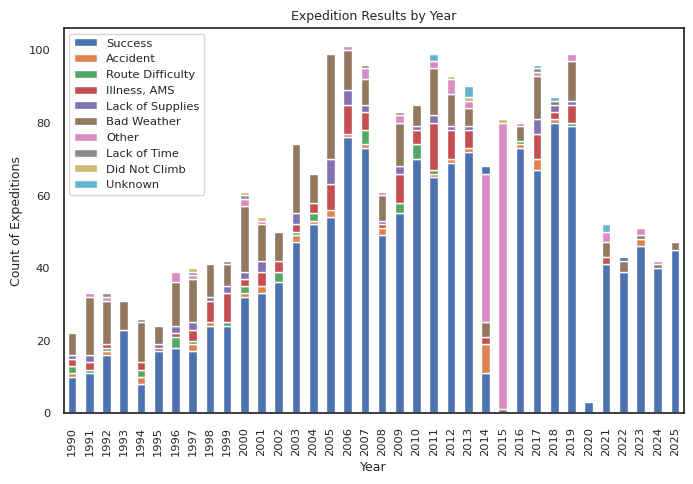

In [10]:
newdf = pd.crosstab(df_recent['Year'], df_recent['result_code'])

ax3 = newdf.plot(kind='bar', stacked=True)
ax3.set_xlabel('Year')
ax3.set_ylabel('Count of Expeditions')
ax3.set_title('Expedition Results by Year')
ax3.legend(['Success', 'Accident', 'Route Difficulty', 'Illness, AMS', 'Lack of Supplies', 'Bad Weather', 'Other', 'Lack of Time', 'Did Not Climb', 'Unknown'])
plt.show()

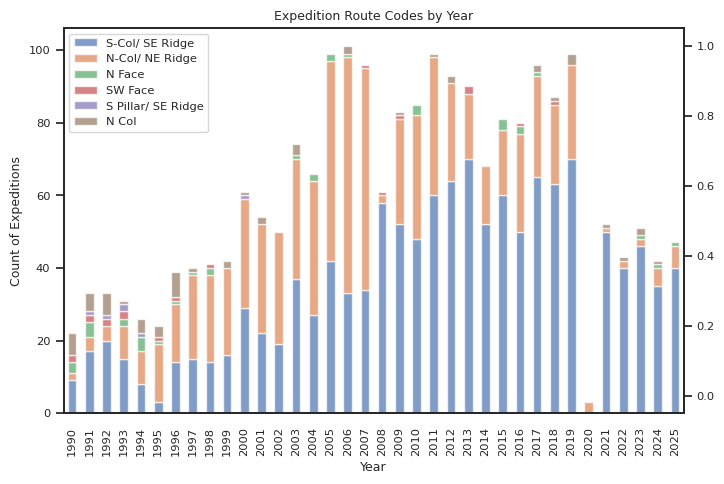

In [15]:
routedf = pd.crosstab(df_recent['Year'], df_recent['route_codes'])

ax4 = routedf.plot(kind='bar', stacked=True, alpha=0.7)
ax5 = ax4.twinx()
ax5.plot(grouped_success['Year'], grouped_success['Sucess_rate'], label='Success Rate', color='green')
ax4.set_xlabel('Year')
ax4.set_ylabel('Count of Expeditions')
ax4.set_title('Expedition Route Codes by Year')
ax4.legend(['S-Col/ SE Ridge', 'N-Col/ NE Ridge', 'N Face', 'SW Face', 'S Pillar/ SE Ridge', 'N Col'])
plt.show()